# 08. Qué comprende FinBERT de nuestras noticias

**Autor: Marco Padilla Gómez. Issue #50.** Diagnóstico de desarrollo, con evaluación humana pendiente.

Este cuaderno estudia cobertura, sensibilidad a la entrada y atribuciones de `ProsusAI/finbert`. No compara otros modelos de lenguaje, no ajusta pesos y no calcula resultados bursátiles. **No hay etiquetas humanas todavía: no se presentan F1 ni exactitud.**

La [guía de evaluación](../docs/finbert_evaluacion_protocolo.md) define muestra, controles y anotación. Quien vaya a anotar no debe consultar predicciones de esos ejemplos antes de etiquetar; el panel reservado no tiene predicciones generadas.

## 1. Procedencia y verificación

El cuaderno lee informes conservados y no ejecuta el modelo ni descarga pesos. Verifica las huellas de los informes, mientras que la reproducción de inferencia usa las dependencias opcionales.

In [1]:
from pathlib import Path
import hashlib
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
RUN = ROOT / 'reports/experiments/finbert-sentiment-20260925'
manifest = json.loads((RUN / 'manifest.json').read_text(encoding='utf-8'))
assert manifest['status'] == 'complete'
prefix = RUN.relative_to(ROOT).as_posix() + '/'
for name, expected in manifest['output_sha256'].items():
    if name.startswith(prefix):
        assert hashlib.sha256((ROOT / name).read_bytes()).hexdigest() == expected, name
status = json.loads((RUN / 'human_evaluation_status.json').read_text(encoding='utf-8'))
assert not status['quality_metrics_computed']
assert not status['evaluation_predictions_computed']
display(pd.Series(status, name='Estado de la evaluación'))

status                                                      pending_human_annotation
primary_labels                                                                     0
secondary_labels                                                                   0
quality_metrics_computed                                                       False
evaluation_predictions_computed                                                False
next_step                          Independent human annotation and adjudication ...
Name: Estado de la evaluación, dtype: object

## 2. Corpus y longitud real

Se auditan las cuatro empresas. Los tokens incluyen los especiales del tokenizador, no son palabras. Las alertas lingüísticas son una heurística basada en palabras funcionales inglesas: **no confirman el idioma**; se requiere revisión humana.

rows                               46223
unique_exact_texts                 38704
groups                             35709
duplicate_ids                          0
cross_boundary_rows                   46
cross_boundary_groups                 14
empty_titles                           0
empty_summaries                       13
empty_texts                            0
rows_over_512_tokens                   0
language_review_flags                102
language_verified                  False
sample_rows                          400
double_annotation_rows                96
sample_context_available             193
sample_multi_company                 115
evaluation_predictions_computed    False
Name: Auditoría, dtype: object

0.5     114.0
0.9     140.0
0.99    166.0
1.0     493.0
Name: Cuantiles de tokens, dtype: float64

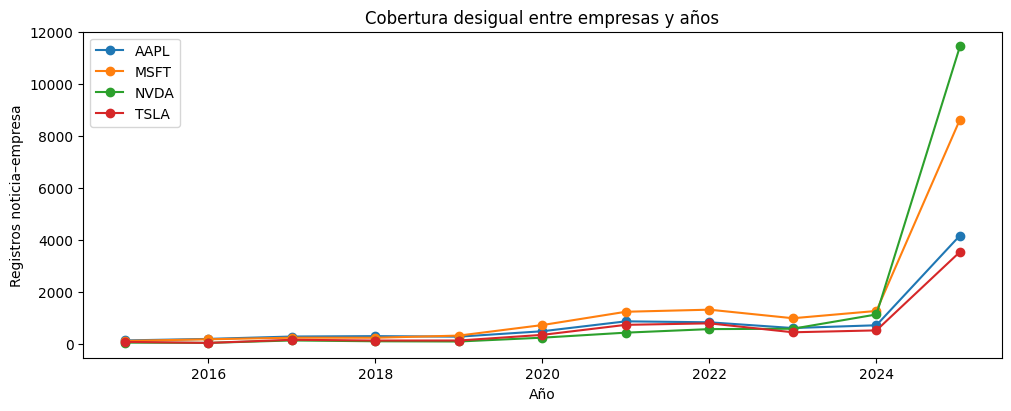

In [2]:
audit = json.loads((RUN / 'audit.json').read_text(encoding='utf-8'))
display(pd.Series({k: v for k, v in audit.items() if k != 'token_quantiles'}, name='Auditoría'))
display(pd.Series(audit['token_quantiles'], name='Cuantiles de tokens'))
coverage = pd.read_csv(RUN / 'coverage.csv')
fig, ax = plt.subplots(figsize=(10, 4), layout='constrained')
for ticker, rows in coverage.groupby('ticker'):
    ax.plot(rows.year, rows.rows, marker='o', label=ticker)
ax.set(xlabel='Año', ylabel='Registros noticia–empresa', title='Cobertura desigual entre empresas y años')
ax.legend()
plt.show()

## 3. Muestra ciega y separación temporal

Se seleccionan 50 parejas por empresa antes y después del 16/10/2023: 400 en total. Los grupos conectan coincidencias de URL, titular o texto y no cruzan particiones; se excluyen los que abarcan ambos periodos. Solo hay una pareja por grupo en la muestra.

El muestreo por hash no utiliza puntuaciones. El equilibrio entre empresas es deliberado y no reproduce la distribución del corpus. Tampoco la selección conserva necesariamente las proporciones de idiomas o clases, aún desconocidas.

In [3]:
registry = pd.read_csv(RUN / 'sample_registry.csv')
primary = pd.read_csv(RUN / 'annotation_primary.csv', keep_default_na=False)
secondary = pd.read_csv(RUN / 'annotation_secondary.csv', keep_default_na=False)
assert registry.group_id.nunique() == len(registry)
assert primary.label.eq('').all() and secondary.label.eq('').all()
a = set(registry.loc[registry.partition == 'development', 'group_id'])
b = set(registry.loc[registry.partition == 'evaluation', 'group_id'])
assert a.isdisjoint(b)
display(registry.groupby(['partition', 'ticker']).size().unstack().rename_axis('Partición'))
print('Parejas:', len(primary), '| Doble anotación prevista:', len(secondary))
print('No se muestran aquí los textos ni se generan predicciones del panel reservado.')

ticker,AAPL,MSFT,NVDA,TSLA
Partición,,,,
development,50,50,50,50
evaluation,50,50,50,50


Parejas: 400 | Doble anotación prevista: 96
No se muestran aquí los textos ni se generan predicciones del panel reservado.


## 4. El problema de la empresa objetivo

FinBERT clasifica el texto presentado; no tiene una entrada específica entrenada para la empresa objetivo. La variante de contexto selecciona el titular y las frases que mencionan un alias explícito. Si no encuentra ninguno, se abstiene.

Esta regla no resuelve pronombres, homónimos ni información implícita. La ausencia de alias no prueba que una noticia sea irrelevante. La anotación debe distinguir sentimiento neutral de información insuficiente.

In [4]:
predictions = pd.read_csv(RUN / 'development_predictions.csv')
assert set(predictions.news_id) == set(registry.loc[registry.partition == 'development', 'news_id'])
predictions = predictions.merge(registry[['news_id', 'ticker']], on='news_id', validate='many_to_one')
context = predictions[predictions.variant == 'company_context'].copy()
context['Disponible'] = context.label.ne('abstain')
display(context.groupby('ticker').agg(Parejas=('news_id', 'size'), Con_contexto=('Disponible', 'sum')))
print('Cobertura global de contexto en la muestra:', audit['sample_context_available'], '/', audit['sample_rows'])

,Parejas,Con_contexto
ticker,,
AAPL,50,22
MSFT,50,22
NVDA,50,34
TSLA,50,22


Cobertura global de contexto en la muestra: 193 / 400


## 5. Sensibilidad a la representación

Comparamos titular, titular y resumen, y contexto explícito. La comparación de contexto usa solo filas donde está disponible. El acuerdo con Alpha Vantage compara dos sistemas de sentimiento, **no mide exactitud**: no disponemos de referencia humana y el proveedor podría utilizar contenido distinto.

In [5]:
agreements = pd.DataFrame(json.loads((RUN / 'development_agreement.json').read_text(encoding='utf-8')))
display(agreements[['first', 'second', 'n', 'agreement']].rename(columns={'first':'Primero', 'second':'Segundo', 'n':'Parejas', 'agreement':'Coincidencia, no exactitud'}))
display(pd.crosstab(predictions.variant, predictions.label))

,Primero,Segundo,Parejas,"Coincidencia, no exactitud"
0,headline,full_text,200,0.555
1,full_text,company_context,100,0.830
2,full_text,alpha_vantage,200,0.490


label,abstain,negative,neutral,positive
variant,,,,
company_context,100,18,28,54
full_text,0,42,60,98
headline,0,32,131,37


## 6. Pruebas lingüísticas controladas

Los seis primeros pares tienen una hipótesis de ordenación: la primera frase debería producir un tono más positivo que la segunda. Son expectativas del diseño, no una referencia humana independiente. El séptimo par intercambia empresas con efectos opuestos y no tiene un orden esperado para el sentimiento global.

Una diferencia positiva no demuestra comprensión general. Una negativa muestra un caso que requiere análisis, no una estimación de la tasa de error en noticias reales.

,Caso,Primera frase,Segunda frase,Etiqueta primera,Etiqueta segunda,Diferencia de tono
0,profits,The company's profits increased.,The company's profits decreased.,positive,negative,1.902566
1,negation,The company expects profits to rise.,The company does not expect profits to rise.,positive,positive,0.025195
2,losses,The company's losses narrowed.,The company's losses widened.,positive,positive,0.311410
3,expectations,Profits rose and exceeded analysts' expectations.,Profits rose but missed analysts' expectations.,positive,positive,0.291330
4,outlook,The company raised its revenue outlook.,The company lowered its revenue outlook.,positive,negative,1.848373
5,litigation,The court dismissed the lawsuit against the company.,The court upheld the lawsuit against the company.,negative,negative,-0.114471
6,mixed_entities,Apple gained market share while Microsoft lost market share.,Microsoft gained market share while Apple lost market share.,negative,negative,0.006328


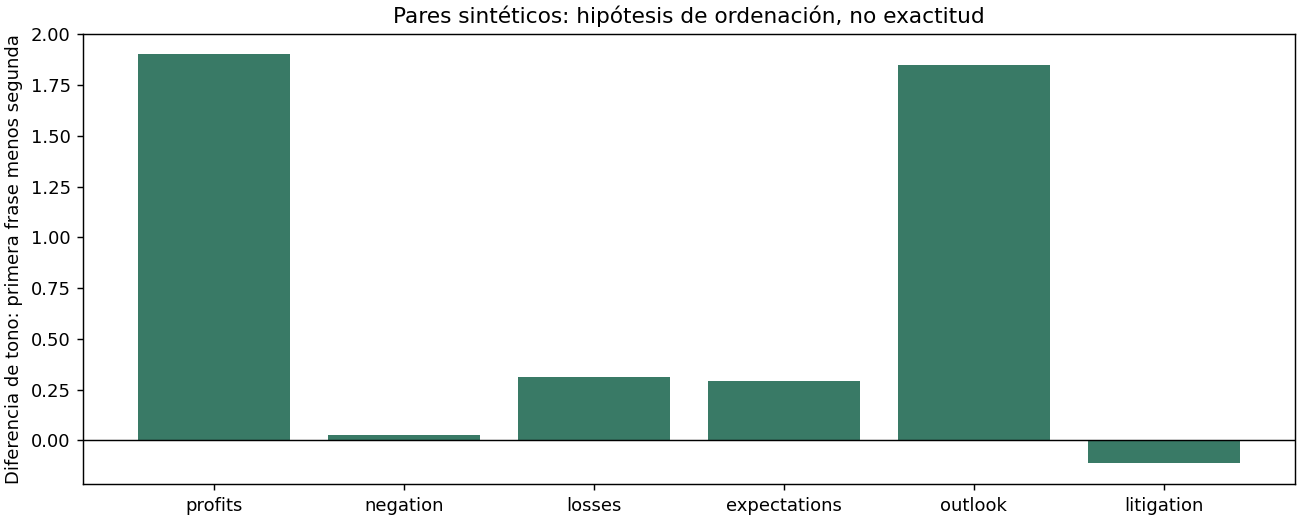

In [6]:
probes = json.loads((RUN / 'controlled_probes.json').read_text(encoding='utf-8'))
probe_rows = [{'Caso': r['probe'], 'Primera frase': r['first_text'], 'Segunda frase': r['second_text'],
               'Etiqueta primera': r['first']['label'], 'Etiqueta segunda': r['second']['label'],
               'Diferencia de tono': r['score_difference']} for r in probes]
with pd.option_context('display.max_colwidth', 120):
    display(pd.DataFrame(probe_rows))
display(Image(filename=str(RUN / 'controlled_probes.png')))

## 7. Gradientes integrados

Para la clase elegida por el modelo se estudia su **logit**, no la probabilidad bursátil. Captum integra gradientes a lo largo del camino entre embeddings de referencia y de entrada:

$$IG_i(x)=(x_i-x'_i)\int_0^1\frac{\partial F(x'+\alpha(x-x'))}{\partial x_i}\,d\alpha.$$

Se mantienen posiciones, segmentos, máscara y tokens especiales. Las referencias PAD y MASK sustituyen únicamente contenido y siguen siendo visibles a la atención. Son entradas artificiales; ninguna equivale a una noticia neutral.

La completitud contrasta la suma de atribuciones con la diferencia de logits. Se aumenta la integración hasta 256 pasos si es necesario. Convergencia numérica no equivale a fidelidad semántica ni causalidad.

,Ejemplo,Origen,Referencia,Clase atribuida,Pasos,Delta,Tolerancia,Convergencia
0,1,synthetic,pad,positive,128,1.653457e-02,0.020329,True
1,1,synthetic,mask,positive,64,-7.764101e-03,0.020206,True
2,2,synthetic,pad,positive,128,6.483793e-03,0.021373,True
3,2,synthetic,mask,positive,64,-1.215696e-03,0.017261,True
4,3,synthetic,pad,positive,32,2.955794e-03,0.015393,True
5,3,synthetic,mask,positive,64,9.235263e-03,0.013972,True
6,4,real_development_headline,pad,neutral,128,7.450581e-08,0.005000,True
7,4,real_development_headline,mask,neutral,64,2.498716e-03,0.005000,True


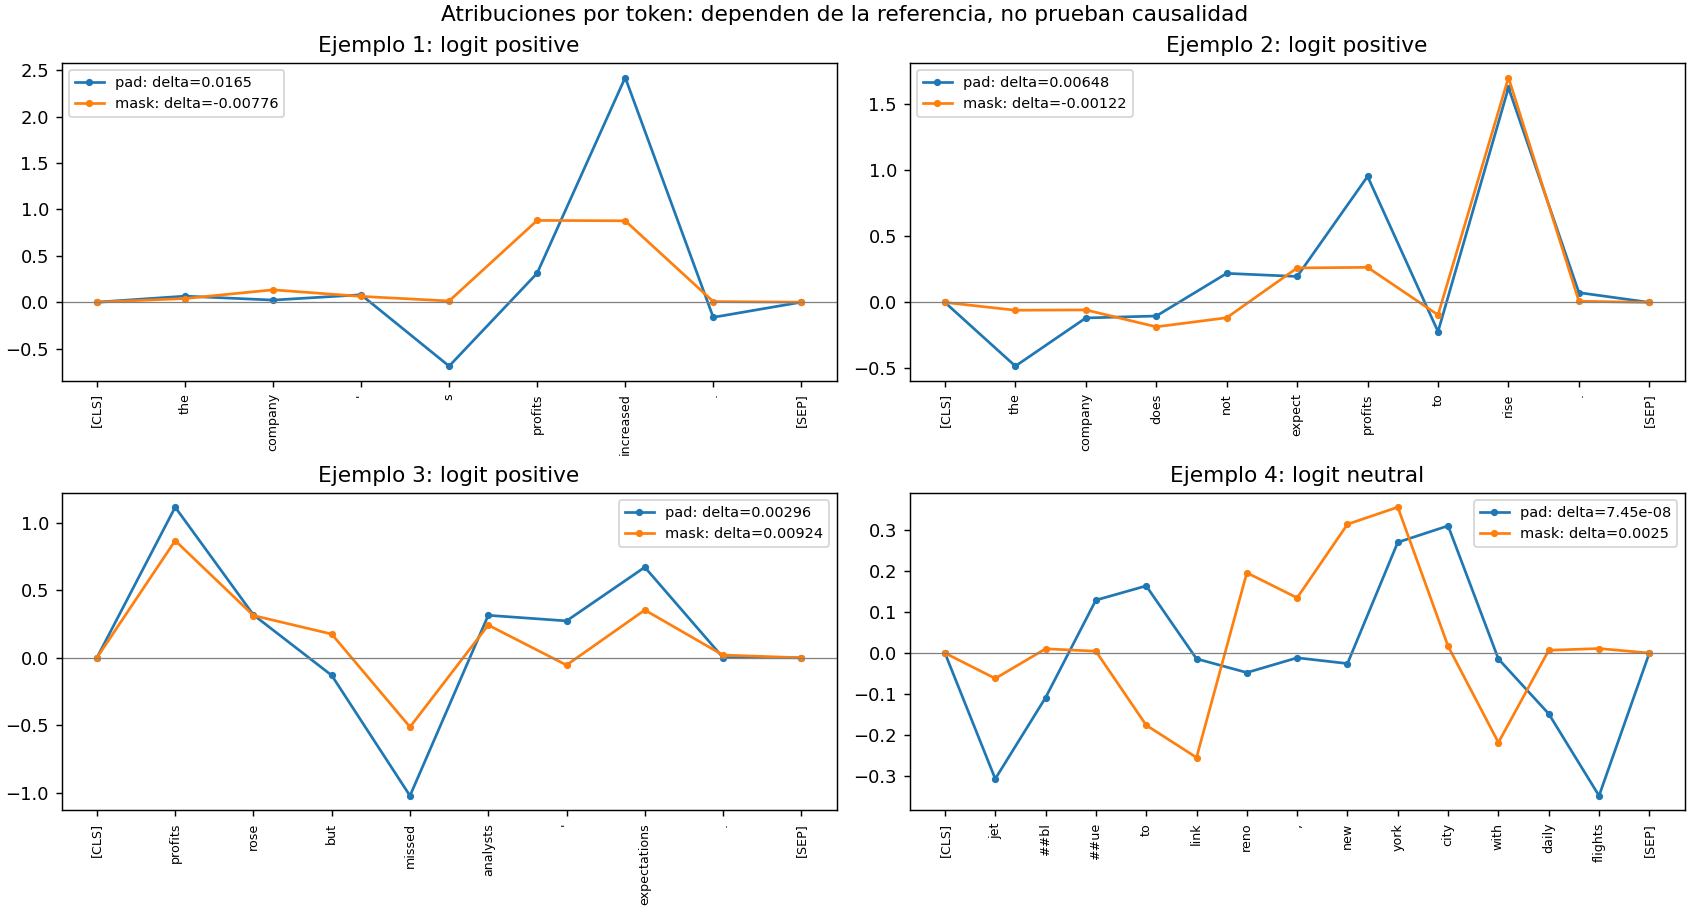

In [7]:
attributions = json.loads((RUN / 'attributions.json').read_text(encoding='utf-8'))
checks = pd.DataFrame([{'Ejemplo': r['example'] + 1, 'Origen': r['kind'], 'Referencia': r['reference'],
                       'Clase atribuida': r['target'], 'Pasos': r['history'][-1]['steps'],
                       'Delta': r['delta'], 'Tolerancia': r['tolerance'], 'Convergencia': r['converged']}
                      for r in attributions])
display(checks)
display(Image(filename=str(RUN / 'attributions.png')))

## 8. Perturbaciones y dependencia de la referencia

Se enmascaran tokens con mayor contribución positiva al logit elegido, igual número con menor magnitud y diez selecciones aleatorias fijas. El presupuesto puede variar entre ejemplos, pero es igual entre controles de una misma atribución.

Una caída positiva significa que el logit original disminuyó. No seleccionamos solo los casos favorables. Los tokens son subpalabras y enmascararlos puede producir entradas artificiales; cuatro ejemplos no validan globalmente un método explicativo.

In [8]:
perturbations = []
for row in attributions:
    for item in row['perturbations']:
        perturbations.append({'Ejemplo': row['example'] + 1, 'Referencia': row['reference'],
                              'Control': 'random' if item['control'].startswith('random') else item['control'],
                              'Caída del logit': item['target_logit_drop']})
perturbations = pd.DataFrame(perturbations)
display(perturbations.groupby(['Ejemplo', 'Referencia', 'Control'])['Caída del logit'].agg(['mean', 'min', 'max']))

mean       min       max
Ejemplo Referencia Control                                      
1       mask       least_magnitude -0.016567 -0.016567 -0.016567
                   random           0.639070 -0.020218  1.073507
                   top_positive     0.450728  0.450728  0.450728
        pad        least_magnitude -0.006780 -0.006780 -0.006780
                   random           0.639070 -0.020218  1.073507
                   top_positive     1.073507  1.073507  1.073507
2       mask       least_magnitude  0.082025  0.082025  0.082025
                   random           0.716010  0.031667  1.241715
                   top_positive     1.241715  1.241715  1.241715
        pad        least_magnitude  0.082025  0.082025  0.082025
                   random           0.716010  0.031667  1.241715
                   top_positive     1.241715  1.241715  1.241715
3       mask       least_magnitude  0.072751  0.072751  0.072751
                   random           0.253310 -0.183216  1.206432
                   top_positive     1.061619  1.061619  1.061619
        pad        least_magnitude  0.072751  0.072751  0.072751
                   random           0.253310 -0.183216  1.206432
                   top_positive     1.061619  1.061619  1.061619
4       mask       least_magnitude  0.363939  0.363939  0.363939
                   random          -0.422315 -0.853381  0.455044
                   top_positive     0.418143  0.418143  0.418143
        pad        least_magnitude -0.470670 -0.470670 -0.470670
                   random          -0.422315 -0.853381  0.455044
                   top_positive    -0.052286 -0.052286 -0.052286

## 9. Historia del checkpoint

Se contrasta la huella de los pesos actuales con el objeto LFS de la primera versión publicada. Esta evidencia permite distinguir disponibilidad del modelo de fecha del experimento. No identifica todos los textos usados durante entrenamiento.

In [9]:
history = json.loads((RUN / 'checkpoint_temporal_audit.json').read_text(encoding='utf-8'))
display(pd.Series({'Mismos pesos que en 2020': history['same_weights_as_2020'],
                   'Huella SHA-256': history['current_local_sha256'],
                   'Consulta': history['consulted_at'], 'Limitación': history['limitation']}))

Mismos pesos que en 2020                                                 True
Huella SHA-256              e15a7b5738df7f17553399b6d94c6e2ff69c89245d066e...
Consulta                                     2026-09-25T10:14:05.543314+00:00
Limitación                  Publication history does not enumerate the tra...
dtype: object

## 10. Qué falta para evaluar calidad

1. El autor debe confirmar y organizar la anotación de las 400 parejas. Las copias de trabajo están en `data/annotations/finbert-sentiment-20260925/` y las plantillas originales se conservan en el informe.
2. Un segundo anotador revisa las 96 parejas prefijadas sin consultar el primero. Se conserva el desacuerdo antes de adjudicar.
3. Se aportan etiquetas, idioma y procedencia completos. Los casos insuficientes o de idioma no confirmado se cuentan y se excluyen del macro-F1 de tres clases.
4. Solo entonces se ejecuta el comando de evaluación del [protocolo](../docs/finbert_evaluacion_protocolo.md). El código rechaza plantillas vacías.

La issue permanece abierta. Estos resultados no demuestran todavía que FinBERT clasifique mejor que Alpha Vantage ni que mejore la predicción bursátil.

### Referencias

[Captum](https://captum.ai/api/integrated_gradients.html), [gradientes integrados](https://proceedings.mlr.press/v70/sundararajan17a.html), [historial de FinBERT](https://huggingface.co/ProsusAI/finbert/commits/main), [protocolo y criterios de anotación](../docs/finbert_evaluacion_protocolo.md).